# Gate B4 — robust innovation IMM только внутри train

## tl;dr

Gate B4 использовал только 911 origins из `t1_v1/train`; исторические validation и раскрытый test не загружались. Последняя train-кампания 2023-11-07 (88 origins) была заранее отделена как внутренний audit-tail, а все параметры выбирались nested rolling resampling внутри outer-train.

`B8_student_t_robust_imm` меняет только Gaussian observation likelihood замороженного B7 на bounded-influence Student-t. Из фиксированной сетки `ν={3,5,10,30}` выбран `ν=30`.

На внутреннем temporal tail общая MAE B8 равна **5.831 мм/год** против **6.015** у B7; leave-zone MAE — **5.858** против **6.046**. Но целевой `volatile_or_gap` MAE стал хуже на **0.45%**, а требовалось улучшение не менее 10%.

Итог: screening не пройден, B8 имеет статус `train_only_research_recorded`, а primary в заранее замороженном наборе для будущего holdout остаётся B7. Новый holdout пока отсутствует (`PENDING_DATA`).

## Context & Methods

Узкая гипотеза: тяжёлые хвосты observation likelihood должны уменьшить влияние больших innovations после gaps/noisy measurements, сохранив динамическую структуру B7.

Для каждой scalar assimilation — settlement, origin-known rate и recent acceleration — Student-t likelihood рассчитывается по базовой innovation variance. Influence weight равен `min(1, (ν+1)/(ν+z²))`, но не ниже 0.05; measurement variance увеличивается обратно пропорционально weight. Все process-noise, retention и Markov-transition параметры B7 неизменны.

Outer evidence включает 1 внутренний temporal tail, 5 rolling-origin, 14 forward leave-profile-out и 4 forward leave-zone-out folds. В каждом outer fit `ν` выбирается на трёх expanding-window inner folds. Objective: 50% normalized overall MAE и 50% normalized `volatile_or_gap` MAE, обе относительно frozen B7 на тех же rows. Thresholds transition proxy fit только на соответствующем train.

Канонический validation остаётся исторической описательной диагностикой Gate B2/B3, но не является источником параметров B8. Test и будущий holdout не имеют executable path в Gate B4 runner.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

root = Path.cwd().resolve()
while not (root / 'pyproject.toml').is_file():
    if root.parent == root:
        raise RuntimeError('Repository root not found')
    root = root.parent

artifact_dir = root / 'artifacts' / 'model_selection' / 't1_b4_train_only_v1'
report = json.loads((artifact_dir / 'gate_b4_report.json').read_text(encoding='utf-8'))
validation = json.loads((artifact_dir / 'validation_report.json').read_text(encoding='utf-8'))
candidate = json.loads((artifact_dir / 'research_candidate.json').read_text(encoding='utf-8'))
suite = json.loads((root / 'artifacts' / 'governance' / 'final_candidate_suite_v3.json').read_text(encoding='utf-8'))
holdout = json.loads((root / 'artifacts' / 'governance' / 'final_holdout_v3_status.json').read_text(encoding='utf-8'))
folds = pd.read_csv(artifact_dir / 'fold_contracts.csv')
tuning = pd.read_csv(artifact_dir / 'robust_tuning.csv')
aggregate = pd.read_csv(artifact_dir / 'aggregate_metrics.csv')
fold_metrics = pd.read_csv(artifact_dir / 'fold_metrics.csv')
transition = pd.read_csv(artifact_dir / 'transition_metrics.csv')
robustness = pd.read_csv(artifact_dir / 'robustness_diagnostics.csv')

pd.set_option('display.max_columns', 30)
{
    'candidate_id': candidate['candidate_id'],
    'candidate_status': candidate['status'],
    'selected_student_t_df': candidate['selected_parameters']['student_t_df'],
    'predeclared_holdout_primary': suite['primary_model_id'],
    'holdout_status': holdout['status'],
    'machine_validation': validation['summary'],
}

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\SUKUNA-AI\\.matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


{'candidate_id': 't1-b4-train-v1-0dedd1296459',
 'candidate_status': 'train_only_research_recorded',
 'selected_student_t_df': 30.0,
 'predeclared_holdout_primary': 'B7_two_regime_imm',
 'holdout_status': 'PENDING_DATA',
 'machine_validation': {'checks': 54, 'failed': 0}}

## Data

In [2]:
pd.DataFrame([
    {
        'source': report['data']['source'],
        'rows': report['data']['rows'],
        'points': report['data']['points'],
        'profiles': report['data']['profiles'],
        'target_date_min': report['data']['target_date_min'],
        'target_date_max': report['data']['target_date_max'],
        'role': 'nested model selection and internal audit',
    },
    {
        'source': 't1_v1/validation',
        'rows': report['data']['historical_validation_rows_loaded'],
        'points': np.nan,
        'profiles': np.nan,
        'target_date_min': None,
        'target_date_max': None,
        'role': 'historical only; not loaded',
    },
    {
        'source': 't1_v1/test',
        'rows': report['data']['current_test_rows_loaded'],
        'points': np.nan,
        'profiles': np.nan,
        'target_date_min': None,
        'target_date_max': None,
        'role': 'disclosed historical diagnostic; not loaded',
    },
])

,source,rows,points,profiles,target_date_min,target_date_max,role
0,t1_v1/train,911,98.0,14.0,2019-02-12,2023-11-07,nested model selection and internal audit
1,t1_v1/validation,0,NaN,NaN,NaN,NaN,historical only; not loaded
2,t1_v1/test,0,NaN,NaN,NaN,NaN,disclosed historical diagnostic; not loaded


In [3]:
fold_summary = folds.groupby('design').agg(
    folds=('fold_id', 'nunique'),
    min_train_rows=('train_rows', 'min'),
    max_train_rows=('train_rows', 'max'),
    validation_rows=('validation_rows', 'sum'),
)
assert (pd.to_datetime(folds['train_target_date_max']) < pd.to_datetime(folds['validation_target_date_min'])).all()
fold_summary

,folds,min_train_rows,max_train_rows,validation_rows
design,,,,
internal_temporal,1,823,823,88
train_leave_profile_out,14,743,786,88
train_leave_zone_out,4,440,749,88
train_rolling_origin,5,619,823,292


## Results

In [4]:
model_order = [
    'B1_persistence_last_rate',
    'B5_fixed_kalman',
    'B6_adaptive_kalman',
    'B7_two_regime_imm',
    'B8_student_t_robust_imm',
]
aggregate.pivot(index='model_id', columns='design', values='mae').loc[model_order].round(3)

design,internal_temporal,train_leave_profile_out,train_leave_zone_out,train_rolling_origin
model_id,,,,
B1_persistence_last_rate,6.104,6.104,6.104,7.091
B5_fixed_kalman,7.194,7.194,7.194,7.123
B6_adaptive_kalman,6.775,6.767,6.727,6.758
B7_two_regime_imm,6.015,6.007,6.046,6.227
B8_student_t_robust_imm,5.831,5.821,5.858,6.509


In [5]:
full_tuning = tuning.loc[
    tuning['tuning_context'].eq('final_spec::full_train'),
    ['student_t_df', 'overall_normalized_mae', 'volatile_or_gap_normalized_mae', 'tuning_score', 'selected'],
]
full_tuning.round(4)

,student_t_df,overall_normalized_mae,volatile_or_gap_normalized_mae,tuning_score,selected
96,3.0,1.0422,1.2766,1.1594,False
97,5.0,1.0472,1.3082,1.1777,False
98,10.0,1.0263,1.1466,1.0865,False
99,30.0,1.0201,1.0072,1.0136,True


In [6]:
internal_transition = transition.loc[
    transition['design'].eq('internal_temporal')
    & transition['scope'].eq('mechanism')
    & transition['model_id'].isin(['B7_two_regime_imm', 'B8_student_t_robust_imm']),
    ['model_id', 'segment', 'rows', 'points', 'profiles', 'mae'],
]
internal_transition.round(3)

,model_id,segment,rows,points,profiles,mae
6,B7_two_regime_imm,accelerating,17,17,6,8.734
7,B8_student_t_robust_imm,accelerating,17,17,6,8.878
13,B8_student_t_robust_imm,decelerating,3,3,3,12.345
14,B7_two_regime_imm,decelerating,3,3,3,17.278
15,B8_student_t_robust_imm,stable,60,60,12,3.710
16,B7_two_regime_imm,stable,60,60,12,3.782
22,B7_two_regime_imm,volatile_or_gap,8,8,5,12.760
24,B8_student_t_robust_imm,volatile_or_gap,8,8,5,12.818


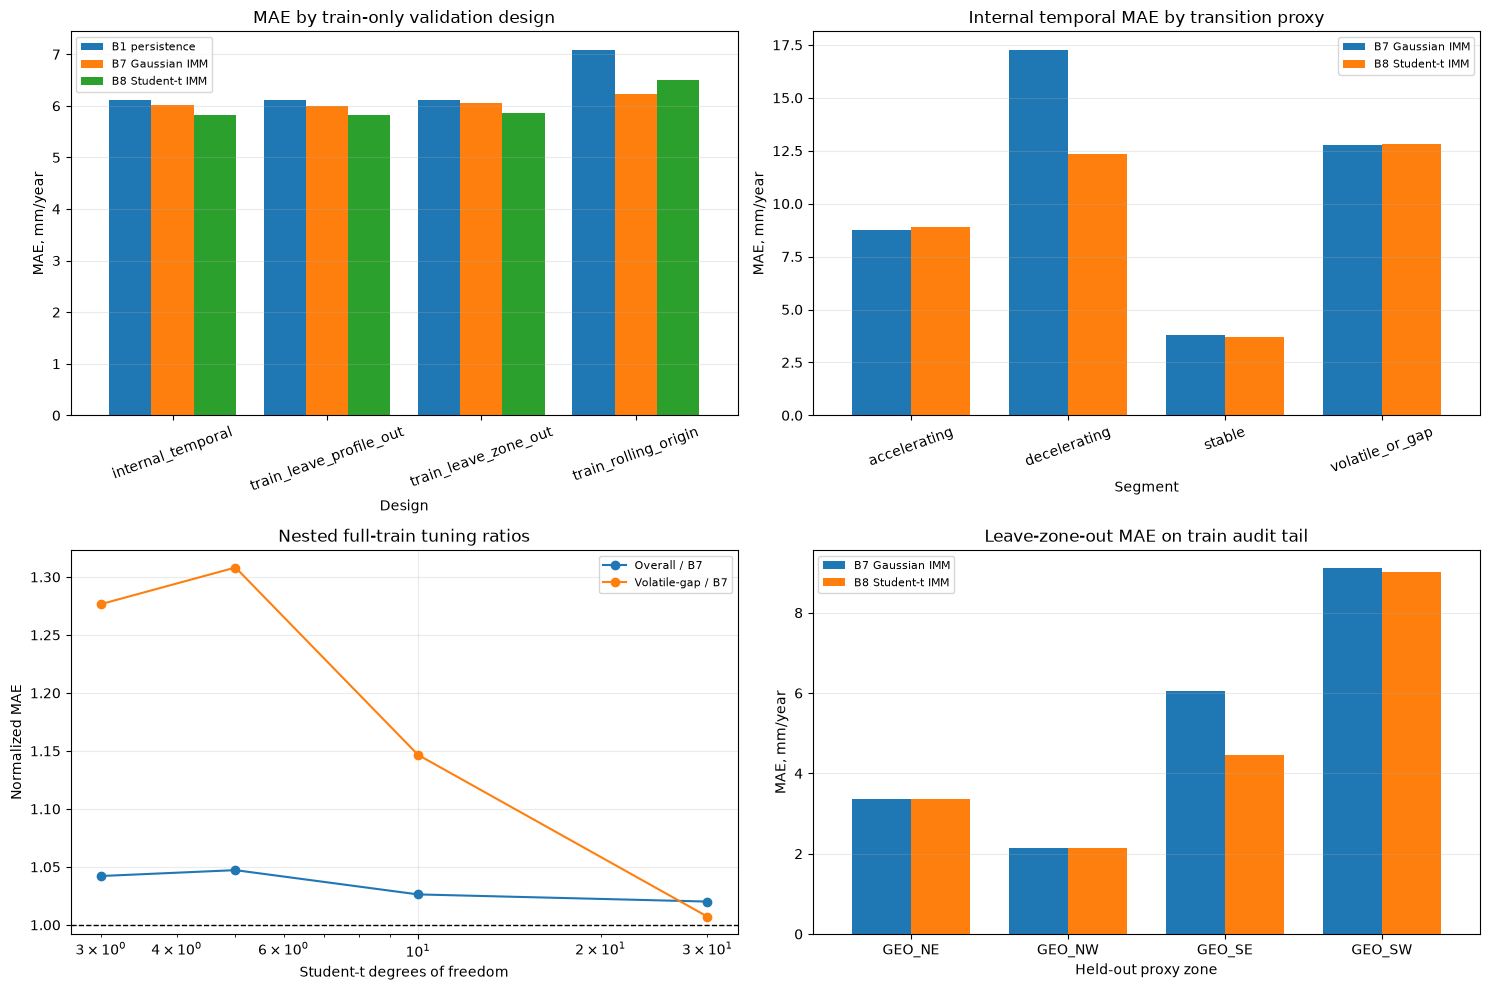

In [7]:
labels = {
    'B1_persistence_last_rate': 'B1 persistence',
    'B7_two_regime_imm': 'B7 Gaussian IMM',
    'B8_student_t_robust_imm': 'B8 Student-t IMM',
}
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

overall = aggregate.loc[aggregate['model_id'].isin(labels)].pivot(
    index='design', columns='model_id', values='mae'
)[list(labels)].rename(columns=labels)
overall.plot(kind='bar', ax=axes[0, 0], width=0.82)
axes[0, 0].set_title('MAE by train-only validation design')
axes[0, 0].set_ylabel('MAE, mm/year')
axes[0, 0].set_xlabel('Design')
axes[0, 0].tick_params(axis='x', rotation=20)
axes[0, 0].grid(axis='y', alpha=0.25)

transition_plot = internal_transition.pivot(index='segment', columns='model_id', values='mae')[
    ['B7_two_regime_imm', 'B8_student_t_robust_imm']
].rename(columns=labels)
transition_plot.plot(kind='bar', ax=axes[0, 1], width=0.75)
axes[0, 1].set_title('Internal temporal MAE by transition proxy')
axes[0, 1].set_ylabel('MAE, mm/year')
axes[0, 1].set_xlabel('Segment')
axes[0, 1].tick_params(axis='x', rotation=20)
axes[0, 1].grid(axis='y', alpha=0.25)

axes[1, 0].plot(full_tuning['student_t_df'], full_tuning['overall_normalized_mae'], marker='o', label='Overall / B7')
axes[1, 0].plot(full_tuning['student_t_df'], full_tuning['volatile_or_gap_normalized_mae'], marker='o', label='Volatile-gap / B7')
axes[1, 0].axhline(1.0, color='black', linestyle='--', linewidth=1)
axes[1, 0].set_xscale('log')
axes[1, 0].set_title('Nested full-train tuning ratios')
axes[1, 0].set_xlabel('Student-t degrees of freedom')
axes[1, 0].set_ylabel('Normalized MAE')
axes[1, 0].grid(alpha=0.25)

zone = fold_metrics.loc[
    fold_metrics['design'].eq('train_leave_zone_out')
    & fold_metrics['model_id'].isin(['B7_two_regime_imm', 'B8_student_t_robust_imm'])
].pivot(index='held_out_group', columns='model_id', values='mae').rename(columns=labels)
zone.plot(kind='bar', ax=axes[1, 1], width=0.75)
axes[1, 1].set_title('Leave-zone-out MAE on train audit tail')
axes[1, 1].set_ylabel('MAE, mm/year')
axes[1, 1].set_xlabel('Held-out proxy zone')
axes[1, 1].tick_params(axis='x', rotation=0)
axes[1, 1].grid(axis='y', alpha=0.25)

for ax in axes.flat:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [8]:
temporal_robustness = robustness.loc[robustness['design'].eq('internal_temporal')]
temporal_robustness.round(4)

,design,fold_id,held_out_group,rows,student_t_df,robust_updates,downweighted_updates,downweighted_update_rate,weighted_mean_influence_weight,minimum_influence_weight,maximum_standardized_innovation_squared
0,internal_temporal,train_tail_2023-11-07,NaN,88,30.0,4488,897,0.1999,0.9776,0.05,816.3525


In [9]:
screening = pd.DataFrame([
    {'criterion': key, 'passed': value}
    for key, value in report['screening']['checks'].items()
])
screening

,criterion,passed
0,accelerating_vs_b7,True
1,internal_temporal_vs_b7,True
2,leave_profile_stability,True
3,leave_zone_stability,True
4,leave_zone_vs_b7,True
5,robust_mechanism_active,True
6,volatile_or_gap_vs_b7,False


In [10]:
assert validation['status'] == 'PASS'
assert validation['summary']['failed'] == 0
assert validation['summary']['checks'] >= 41
assert report['historical_validation_loaded'] is False
assert report['current_t1_test_loaded'] is False
assert report['new_final_holdout_loaded'] is False
assert candidate['selection_data'] == ['t1_v1/train']
assert suite['primary_model_id'] == 'B7_two_regime_imm'
assert suite['primary_selected_from_holdout'] is False
assert holdout['status'] == 'PENDING_DATA'
{
    'qa': validation['summary'],
    'candidate_status': candidate['status'],
    'screening_passed': candidate['screening_passed'],
    'holdout_primary': suite['primary_model_id'],
    'new_holdout_status': holdout['status'],
}

{'qa': {'checks': 54, 'failed': 0},
 'candidate_status': 'train_only_research_recorded',
 'screening_passed': False,
 'holdout_primary': 'B7_two_regime_imm',
 'new_holdout_status': 'PENDING_DATA'}

## Takeaways

1. **B8 не подтвердил узкую гипотезу.** В full-train nested tuning даже лучший `ν=30` имеет objective 1.0136; `volatile_or_gap` normalized MAE равна 1.0072, то есть хуже B7. На 8 rows внутреннего temporal tail B8 также хуже B7 на 0.45%, далеко от порога +10%.
2. **Общая и spatial ошибки улучшились локально.** Internal temporal MAE ниже B7 на 3.06%, leave-profile на 3.09%, leave-zone на 3.12%; spatial degradation к собственному temporal B8 менее 0.5%.
3. **Rolling evidence предостерегает от повышения статуса.** На 292 pooled rolling origins B8 хуже B7 по MAE на 4.52%.
4. **Robust mechanism действительно активен.** На внутреннем temporal tail downweighted 897 из 4488 regime-channel updates; это доказывает работу механизма, но не целевое улучшение качества.
5. **Governance не меняется по результату.** B8 остаётся `train_only_research_recorded`; заранее объявленный primary для one-shot future/external holdout — B7. B1/B5/B6/B8 будут только контекстными comparators, без выбора победителя после открытия.
6. **Финальная внешняя валидность пока неизвестна.** Реального нового пакета нет, статус intake — `PENDING_DATA`; synthetic fixtures и старые validation/test не заменяют честный holdout.